# Pancreatic Cancer Classification from Liquid Biopsy Platelet RNA-seq Data

This notebook presents the step-by-step solution for classifying pancreatic cancer based on gene expression data obtained from platelet RNA-seq.

Goal: Build a binary classifier distinguishing pancreatic cancer samples from controls (healthy + pancreatic diseases).

---

## 1. Loading the dataset

The data consists of two files:
- counts_pancreatic.csv - gene expression matrix (genes x samples), transposed so that rows correspond to samples and columns to genes.
- samples_pancreatic.xlsx - sample metadata (Group, Sex, Age, Stage, etc.).

Both files are joined on shared sample indices. The resulting Dataset object contains:
- X - DataFrame with gene expression values
- y - class label (Group)
- meta - full metadata
- age, sex - helper columns

In [1]:
# Install required packages
!pip install numpy pandas matplotlib scikit-learn seaborn openpyxl statsmodels plotly kaleido nbformat --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, balanced_accuracy_score, f1_score

from utilz.Dataset import load_dataset
from utilz.constans import HEALTHY, DISEASE, CANCER
from utilz.helpers import plot_split_balance, plot_pca, plot_group_overview
from utilz.preprocessing_utilz import (
    ConstantExpressionReductor, AnovaFdrReductor,
    MeanExpressionReductor,  WithinGroupVarianceReductor
)


meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"

ds = load_dataset(data_path, meta_path, label_col="Group")

# Constants
TEST_SIZE = 0.2
VALID_SIZE = 0.2
# Preprocessing hyperparameters
ANOVA_FDR_THRESHOLD = 0.05
MEAN_THRESHOLD = 5

LOG2FC_THRESHOLD = np.log(1.2)


print(f"Number of samples: {ds.X.shape[0]}")
print(f"Number of genes:   {ds.X.shape[1]}")
print(f"\nOriginal class distribution:")
print(ds.y.value_counts())

[INFO] skipped 1973 probs due to missing metadata
Dropping inconsistent sample:
                        Sex   Age                Group   Institution  \
Vumc-ChronPan-29-TR1045   M  58.0  Pancreatic diseases  Institute 13   

                         Lib.size Stage RealLocation    Mode  CA125  \
Vumc-ChronPan-29-TR1045   1493422    IV         VUMC  Single    NaN   

                         Platelets Histology   Datasplit Gdansk_sample_name  \
Vumc-ChronPan-29-TR1045        NaN       NaN  Validation                NaN   

                        StageFull  LeukoMichal      PTPRC  
Vumc-ChronPan-29-TR1045        IV  7726.550165  97.092449  
Number of samples: 583
Number of genes:   42630

Original class distribution:
Group
Asymptomatic controls    410
Pancreatic cancer        124
Pancreatic diseases       49
Name: count, dtype: int64


### 1.1. Metadata overview

Overview of sample metadata - demographic and clinical variables that may be potential sources of bias.

In [3]:
ds.meta.head()

,Sex,Age,Group,Institution,Lib.size,Stage,RealLocation,Mode,CA125,Platelets,Histology,Datasplit,Gdansk_sample_name,StageFull,LeukoMichal,PTPRC
AMC-HD-001-TR1139,M,23.0,Asymptomatic controls,Institute 1,1065633,NaN,AMC,Single,NaN,NaN,NaN,Train,NaN,n.a.,9257.408507,167.036869
AMC-HD-002-TR1140,F,20.0,Asymptomatic controls,Institute 1,1126605,NaN,AMC,Single,NaN,NaN,NaN,Test,NaN,n.a.,7145.361506,47.043995
AMC-HD-003-TR1141,F,21.0,Asymptomatic controls,Institute 1,698667,NaN,AMC,Single,NaN,NaN,NaN,Validation,NaN,n.a.,10362.590476,88.740416
AMC-HD-004-TR1142,F,21.0,Asymptomatic controls,Institute 1,850492,NaN,AMC,Single,NaN,NaN,NaN,Train,NaN,n.a.,5721.394205,23.515800
AMC-HD-005-TR1143,F,21.0,Asymptomatic controls,Institute 1,824835,NaN,AMC,Single,NaN,NaN,NaN,Test,NaN,n.a.,14561.700219,58.193457


In [4]:

m_healthy = ds.y == HEALTHY
m_disease = ds.y == DISEASE
m_cancer  = ds.y == CANCER
m_hd      = m_healthy | m_disease

groups = {
    "Healthy":             m_healthy,
    "Other diseases":      m_disease,
    "Cancer":              m_cancer,
    "Healthy + other dis.":m_hd,
    "All":                 np.ones(len(ds.y), dtype=bool),
}

for name, mask in groups.items():
    meta = ds.meta[mask]
    age  = ds.age[mask]
    sex  = ds.sex[mask]
    n    = mask.sum()
    print(f"\n=== {name} (n={n}) ===")
    print(f"  Age: mean {age.mean():.1f} ± {age.std():.1f}, "
          f"median {age.median():.0f}, range {age.min():.0f}–{age.max():.0f}")
    for s, cnt in sex.value_counts().items():
        print(f"  Sex {s}: {cnt} ({cnt/n*100:.1f}%)")
    if name == "Cancer":
        for st, cnt in meta["Stage"].value_counts().sort_index().items():
            print(f"  Stage {st}: {cnt} ({cnt/n*100:.1f}%)")



=== Healthy (n=410) ===
  Age: mean 48.7 ± 15.8, median 51, range 18–86
  Sex F: 238 (58.0%)
  Sex M: 157 (38.3%)
  Sex n.a.: 15 (3.7%)

=== Other diseases (n=49) ===
  Age: mean 63.6 ± 10.8, median 65, range 39–82
  Sex F: 27 (55.1%)
  Sex M: 22 (44.9%)

=== Cancer (n=124) ===
  Age: mean 67.1 ± 9.8, median 68, range 42–87
  Sex M: 73 (58.9%)
  Sex F: 51 (41.1%)
  Stage I: 3 (2.4%)
  Stage II: 64 (51.6%)
  Stage III: 31 (25.0%)
  Stage IV: 25 (20.2%)

=== Healthy + other dis. (n=459) ===
  Age: mean 50.4 ± 16.0, median 53, range 18–86
  Sex F: 265 (57.7%)
  Sex M: 179 (39.0%)
  Sex n.a.: 15 (3.3%)

=== All (n=583) ===
  Age: mean 54.1 ± 16.4, median 56, range 18–87
  Sex F: 316 (54.2%)
  Sex M: 252 (43.2%)
  Sex n.a.: 15 (2.6%)


In [5]:
from pathlib import Path

OUT_DIR = Path("group_overview").resolve()
OUT_DIR.mkdir(exist_ok=True)


def make_group(mask):
    return (
        ds.y[mask].reset_index(drop=True),
        ds.sex[mask].reset_index(drop=True),
        ds.age[mask].reset_index(drop=True),
        ds.meta['Stage'][mask].reset_index(drop=True),
    )

m_healthy = ds.y == HEALTHY
m_disease = ds.y == DISEASE
m_cancer  = ds.y == CANCER
m_hd      = m_healthy | m_disease

splits_by_group = {
    'Healthy':         make_group(m_healthy),
    'Disease':         make_group(m_disease),
    'Cancer':          make_group(m_cancer),
    'Healthy+Disease': make_group(m_hd),
}

libsize_by_group = {
    'Healthy':         np.log10(ds.meta.loc[m_healthy, 'Lib.size'].astype(float).values),
    'Disease':         np.log10(ds.meta.loc[m_disease, 'Lib.size'].astype(float).values),
    'Cancer':          np.log10(ds.meta.loc[m_cancer,  'Lib.size'].astype(float).values),
    'Healthy+Disease': np.log10(ds.meta.loc[m_hd,      'Lib.size'].astype(float).values),
}

fig = plot_group_overview(
    splits_by_group,
    colors={
        'Healthy':         '#22c55e',
        'Disease':         '#f59e0b',
        'Cancer':          '#ef4444',
        'Healthy+Disease': '#6366f1',
    },
    libsize_data=libsize_by_group,
    save_path=OUT_DIR / "group_overview.png",
)

[OK] zapisano: C:\Users\kasia\Desktop\magisterka\pancreatic_canacer_dataset_analysis\group_overview\group_overview.png


---

## 2. Label preparation - binary classification

The dataset contains three original classes:
- Asymptomatic control - healthy individuals
- Pancreatic diseases - other pancreatic conditions
- Pancreatic cancer - pancreatic cancer

The goal is to detect pancreatic cancer, so we merge Asymptomatic controls and Pancreatic diseases into a single control class. The problem becomes binary classification:

| New label | Original classes |
|---|---|
| 0 - Control | Asymptomatic controls + Pancreatic diseases |
| 1 - Cancer | Pancreatic cancer |

In [6]:
ds.y = ds.y.replace({DISEASE: HEALTHY})

print("Class distribution after merging:")
print(ds.y.value_counts())
print(f"\nClass ratio (control/cancer): {(ds.y == HEALTHY).sum() / (ds.y == CANCER).sum():.2f}")

Class distribution after merging:
Group
Asymptomatic controls    459
Pancreatic cancer        124
Name: count, dtype: int64

Class ratio (control/cancer): 3.70


In [7]:
# Encode labels numerically
le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)

print("Class mapping:")
print(f"{le.classes_[0]} -> {le.transform(le.classes_)[0]}")
print(f"{le.classes_[1]} -> {le.transform(le.classes_)[1]}")

print("Encoded label distribution:")
print(y_encoded.value_counts().sort_index())

Class mapping:
Asymptomatic controls -> 0
Pancreatic cancer -> 1
Encoded label distribution:
0    459
1    124
Name: count, dtype: int64


### 2.2. Expression matrix - basic statistics

In [8]:
"""
print(f"Shape (samples x genes): {ds.X.shape[0]} x {ds.X.shape[1]}")
print(f"Value range: [{ds.X.min().min():.2f}, {ds.X.max().max():.2f}]")
print(f"Missing values: {ds.X.isna().sum().sum()}")

ds.X.head(10).describe()
"""

'\nprint(f"Shape (samples x genes): {ds.X.shape[0]} x {ds.X.shape[1]}")\nprint(f"Value range: [{ds.X.min().min():.2f}, {ds.X.max().max():.2f}]")\nprint(f"Missing values: {ds.X.isna().sum().sum()}")\n\nds.X.head(10).describe()\n'

{'log2fc': array([-0.04561347,  0.        , -0.38165335, ...,  0.02024194,
         0.0134481 , -0.00197821], shape=(42630,)),
 'p_values': array([3.03622986e-01, 2.37392730e-05, 5.28009565e-04, ...,
        9.21154482e-04, 2.67503241e-01, 4.63021623e-01], shape=(42630,)),
 'significant': array([False, False,  True, ..., False, False, False], shape=(42630,)),
 'reductor': Log2FCReductor(min_abs_log2fc=np.float64(0.1823215567939546))}

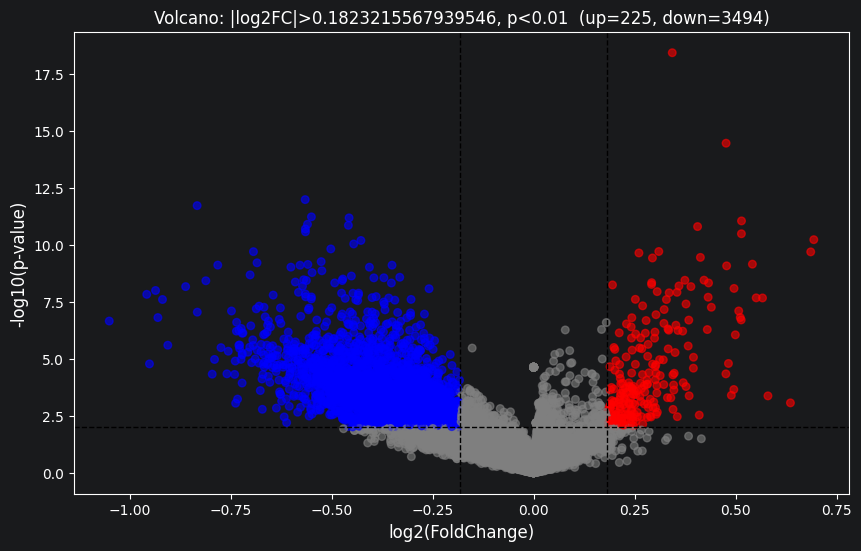

In [9]:
from utilz.preprocessing_utilz import Log2FCReductor
from sklearn.feature_selection import f_classif

def create_volcano_plot(X, y, p_threshold=0.01, min_abs_log2fc=LOG2FC_THRESHOLD):
    reductor = Log2FCReductor(min_abs_log2fc=min_abs_log2fc).fit(X, y)
    log2fc = reductor.log2fc_.values
    deg_mask = X.columns.isin(reductor.selected_genes_)
    _, p_values = f_classif(X, y)
    neg_log10_p = -np.log10(p_values + 1e-300)
    sig_p = p_values < p_threshold
    up    = deg_mask & sig_p & (log2fc > 0)
    down  = deg_mask & sig_p & (log2fc < 0)

    colors = np.array(['grey'] * len(log2fc))
    colors[up]   = 'red'
    colors[down] = 'blue'

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(log2fc, neg_log10_p, c=colors, alpha=0.6, s=30)
    ax.axhline(-np.log10(p_threshold), color='black', linestyle='--', linewidth=1)
    ax.axvline( min_abs_log2fc, color='black', linestyle='--', linewidth=1)
    ax.axvline(-min_abs_log2fc, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('log2(FoldChange)', fontsize=12)
    ax.set_ylabel('-log10(p-value)', fontsize=12)
    ax.set_title(f'Volcano: |log2FC|>{min_abs_log2fc}, p<{p_threshold}  '
                 f'(up={int(up.sum())}, down={int(down.sum())})')

    return {
        'log2fc':      log2fc,
        'p_values':    p_values,
        'significant': up | down,
        'reductor':    reductor,
    }


create_volcano_plot(ds.X, y_encoded, p_threshold=0.01, min_abs_log2fc = LOG2FC_THRESHOLD)

---

## 3. Train / Test / Validation split

The data is split as follows:
- 60% - training set
- 20% - validation set (used for decision threshold tuning)
- 20% - test set (used for final model evaluation)

### Stratification

To avoid bias in the split, we apply combined stratification across four variables:
1. Class (y) - cancer vs. control
2. Sex
3. Age group (Age quantiled into 3 bins: young/mid/old)
4. Stage (grouped as I_II / III / IV)

This ensures that each subset maintains similar proportions of these variables, minimizing the risk of confounding.

In [10]:
X_train, X_test, X_valid, y_train, y_test, y_valid = (
    ds.get_train_test_valid_split(ds.X, y_encoded, test_size=TEST_SIZE, valid_size=VALID_SIZE)
)

# zbior walidacyjny doklejamy do testowego; dalej uzywamy tylko train i test
X_test = pd.concat([X_test, X_valid])
y_test = pd.concat([y_test, y_valid])
del X_valid, y_valid

print("Split sizes:")
print(f"  Train: {X_train.shape[0]} samples ({X_train.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]} samples ({X_test.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Total: {X_train.shape[0] + X_test.shape[0]} samples")
print(f"\nNumber of features: {X_train.shape[1]}")


[INFO] 7 samples with unique strata added to train set
[INFO] 4 samples with unique strata (2nd split) added to train set

[ASSERTION PASSED] No leakage detected between splits.
Split sizes:
  Train: 356 samples (61.1%)
  Test:  227 samples (38.9%)
  Total: 583 samples

Number of features: 42630


### 3.1. Split balance overview

Class counts, proportions, and demographic distributions across train/test/validation splits.

In [11]:
split_summary = pd.DataFrame({
    'Train': y_train.value_counts().sort_index(),
    'Test': y_test.value_counts().sort_index(),
})
split_summary.index = [le.inverse_transform([i])[0] for i in split_summary.index]

split_pct = pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True).sort_index() * 100,
    'Test (%)': y_test.value_counts(normalize=True).sort_index() * 100,
})
split_pct.index = split_summary.index
combined = pd.DataFrame({
    'Train': split_summary['Train'].astype(str) + ' (' + split_pct['Train (%)'].round(1).astype(str) + '%)',
    'Test': split_summary['Test'].astype(str) + ' (' + split_pct['Test (%)'].round(1).astype(str) + '%)',
})

totals = split_summary.sum()
combined.loc['Total'] = [str(totals['Train']), str(totals['Test'])]

display(combined)

plot_split_balance({
    'Train': (y_train, ds.sex.loc[X_train.index], ds.age.loc[X_train.index], ds.meta["Stage"].loc[X_train.index].replace({'I': 'I-II', 'II': 'I-II'})),
    'Test':  (y_test,  ds.sex.loc[X_test.index],  ds.age.loc[X_test.index],  ds.meta["Stage"].loc[X_test.index].replace({'I': 'I-II', 'II': 'I-II'})),
})



,Train,Test
Asymptomatic controls,275 (77.2%),184 (81.1%)
Pancreatic cancer,81 (22.8%),43 (18.9%)
Total,356,227


### 3.2. Data leakage check

Verify that no sample appears in more than one split.

In [12]:
train_test_overlap = X_train.index.intersection(X_test.index)
print(f"Overlap Train - Test: {len(train_test_overlap)}")
assert len(train_test_overlap) == 0, "Data leakage"
print("\nNo data leakage - train and test are disjoint.")


Overlap Train - Test: 0

No data leakage - train and test are disjoint.


---

## 4. Preprocessing - feature reduction pipeline

The preprocessing pipeline reduces 42,630 genes to a manageable set by sequentially applying:

| Step | Reducer                                    | Purpose |
|---|--------------------------------------------|---|
| 1 | **ConstantExpressionReductor**             | Remove genes with zero variance (single unique value) |
| 2 | **AnovaReductor** (percentile=60)          | Keep top 30% genes by ANOVA F-score vs. class label |
| 3 | **MeanExpressionReductor** (percentile=20) | Remove bottom 10% by mean expression level |
| 4 | **AgeBiasTransformer**                        | Remove genes significantly correlated with age (OLS + FDR-BH) |
| 5 | **SexBiasReductor**                        | Remove genes significantly correlated with sex (OLS + FDR-BH) |
| 6 | **StandardScaler**                         | Zero-mean, unit-variance normalization |

All reductors are fit on the training set only and applied to validation/test sets to prevent data leakage.

### 4.1. Pipeline definition and gene reduction summary

In [13]:
from utilz.multi_residual_bootstrap import MultiCovariateResidualBootstrapTransformer

from utilz.multi_residual_bootstrap import (
    MultiCovariateResidualBootstrapTransformer, build_covariates,
)

cov = build_covariates(ds.meta)
sex_numeric = ds.sex.map({"F": 0, "M": 1})


pipeline = Pipeline([
        ('ConstantExpressionReductor', ConstantExpressionReductor()),
        ('AnovaFDRReductor', AnovaFdrReductor(alpha=ANOVA_FDR_THRESHOLD)),
        ('MeanExpressionReductor', MeanExpressionReductor(MEAN_THRESHOLD)),
        ('multi_resid', MultiCovariateResidualBootstrapTransformer(
            covariates=cov, labels=y_train,
            n_bootstrap=1000, fdr_alpha=0.05, min_r2=0.05, cv_threshold_pct=30.0,
        )),
])

step_names = []
step_counts = []
step_genes = {}

X_current = X_train.copy()
step_names.append("Raw input")
step_counts.append(X_current.shape[1])
step_genes["Raw input"] = list(X_current.columns)

for name, transformer in pipeline.steps:
    if name == 'scaler':
        transformer.fit(X_current)
        X_current = pd.DataFrame(
            transformer.transform(X_current),
            columns=X_current.columns, index=X_current.index
        )
    else:
        transformer.fit(X_current, y_train)
        X_current = transformer.transform(X_current)
    step_names.append(name)
    step_counts.append(X_current.shape[1])
    if name != 'scaler':
        step_genes[name] = list(transformer.selected_genes_)

# Summary table
reduction_df = pd.DataFrame({
    'Step': step_names,
    'Genes remaining': step_counts,
    'Genes removed': [0] + [step_counts[i] - step_counts[i+1] for i in range(len(step_counts)-1)],
})
reduction_df['% of original'] = (reduction_df['Genes remaining'] / step_counts[0] * 100).round(1)

print(f"Preprocessing pipeline: {step_counts[0]} → {step_counts[-1]} genes\n")
reduction_df

data shape after ConstantExpressionReductor:  (356, 30588)
data shape after AnovaFdrReductor:  (356, 4006)
data shape after MeanExpressionReductor:  (356, 3805)


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('default')

label_map = {
    "Raw input":                  "Dane wejściowe",
    "ConstantExpressionReductor": "Usunięcie genów stałych",
    "AnovaFdrReductor":           "ANOVA z korekcją FDR",
    "MeanExpressionReductor":     "Filtr średniej ekspresji",
}

pl_names, pl_counts = [], []
for name, count in zip(step_names, step_counts):
    if name == "multi_resid":
        continue
    pl_names.append(label_map.get(name, name))
    pl_counts.append(count)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('white')
colors = ['#6366f1', '#8b5cf6', '#a78bfa', '#c4b5fd']
ax.bar(range(len(pl_names)), pl_counts, color=colors[:len(pl_names)])

for i, count in enumerate(pl_counts):
    removed = f"\n(usunięto {pl_counts[i-1] - count})" if i > 0 and pl_counts[i-1] != count else ""
    label = f"{count:,}".replace(",", " ") + removed
    ax.text(i, count + 500, label, ha='center', va='bottom', fontsize=10)

ax.set_xticks(range(len(pl_names)))
ax.set_xticklabels(pl_names, rotation=20, ha='right')
ax.set_ylabel("Liczba genów")
ax.set_title("Redukcja liczby genów po kolejnych krokach selekcji")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("redukcja_genow.png", dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

### 4.2. PCA before and after preprocessing

PCA visualization on the test set

In [ ]:
num_pca_components = 3

print("=== PCA BEFORE preprocessing ===")
plot_pca(X_test, y_test, num_pca_components, le)

X_test_filtered = pipeline.transform(X_test)
print(f"\n=== PCA AFTER preprocessing ({X_test_filtered.shape[1]} genes) ===")
plot_pca(X_test_filtered, y_test, num_pca_components, le)


### 4.3. ANOVA filtering effect

The AnovaReductor keeps the top genes by ANOVA F-score (within-class / between-class variances).

In [ ]:
"""
wgv_red = pipeline.named_steps['WithinGroupVarianceReductor']

wgv          = wgv_red.wgv_
p_corr       = wgv_red.pvalues_corrected_
sigma2_ref   = wgv_red.sigma2_ref_
kept_genes   = wgv_red.selected_genes_
kept_mask    = wgv.index.isin(kept_genes)
removed_wgv = wgv[~kept_mask]
wgv_crit = removed_wgv.min() if len(removed_wgv) else np.nan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sorted_idx = np.argsort(wgv.values)
sorted_wgv = wgv.values[sorted_idx]
sorted_kept = kept_mask[sorted_idx]
colors = np.where(sorted_kept, 'tab:blue', 'tab:red')
ax.scatter(np.arange(len(sorted_wgv)), sorted_wgv, c=colors, s=1, alpha=0.5)
ax.axhline(sigma2_ref, color='black', ls='-', lw=1.2,
           label=f'sigma^2_ref (median) = {sigma2_ref:.4g}')
if np.isfinite(wgv_crit):
    ax.axhline(wgv_crit, color='orange', ls='--', lw=1.5,
               label=f'wgv_crit (alpha={wgv_red.alpha}, FDR) = {wgv_crit:.4g}')
ax.set(xlabel='Genes (sorted by WGV)',
       ylabel='Pooled within-group variance',
       title='WGV ranking (blue = kept, red = removed)')
ax.legend(fontsize=9)

# panel 2: volcano-style WGV vs -log10(p_corr)
ax = axes[1]
neg_log10_p = -np.log10(p_corr.values + 1e-300)
colors2 = np.where(kept_mask, 'tab:blue', 'tab:red')
ax.scatter(wgv.values, neg_log10_p, c=colors2, s=4, alpha=0.4)
ax.axhline(-np.log10(wgv_red.alpha), color='orange', ls='--', lw=1.2,
           label=f'-log10(alpha) = {-np.log10(wgv_red.alpha):.2f}')
ax.axvline(sigma2_ref, color='black', ls='-', lw=1.0,
           label=f'sigma^2_ref = {sigma2_ref:.4g}')
ax.set(xlabel='Within-group variance', ylabel='-log10(p_corr)',
       title='Significance vs WGV')
ax.legend(fontsize=9)

plt.suptitle(
    f'WithinGroupVarianceReductor (chi^2 vs sigma^2_ref="median", '
    f'alpha={wgv_red.alpha}, FDR=BH): '
    f'{len(wgv)} -> {kept_mask.sum()} genes  '
    f'(usunieto {(~kept_mask).sum()} genow z istotnie duza WGV)',
    fontsize=12,
)
plt.tight_layout()
plt.show()
"""

---

## 5. Testy rezydualizacji

Walidacja korekcji rezydualizacyjnej (multi_resid) na pełnym zbiorze genów, bez selekcji różnicowo eksprymowanych genów. Sprawdzamy, czy po korekcji maleje możliwość przewidzenia zmiennych zakłócających (wiek, płeć, głębokość sekwencjonowania) na podstawie ekspresji.

Transformacje (usunięcie genów stałych oraz kosztowny multi_resid) liczone są raz i reużywane dla wszystkich trzech celów. Wiek i głębokość sekwencjonowania oceniane są regresją grzbietową, a płeć regresją logistyczną. Skuteczna korekcja powinna obniżyć R^2 oraz zbalansowaną dokładność w stronę wartości baseline.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

BASE_SEED     = 2137
GRID_CV_FOLDS = 10


# ---------------------------------------------------------------------------
# Przygotowanie macierzy: po filtrach (raw) i po filtrach + residualizacji (corr)
# ---------------------------------------------------------------------------
filter_pipe = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaFDRReductor',           AnovaFdrReductor(alpha=ANOVA_FDR_THRESHOLD)),
    ('MeanExpressionReductor',     MeanExpressionReductor(MEAN_THRESHOLD)),
]).fit(X_train, y_train)
Xtr_raw = filter_pipe.transform(X_train)
Xte_raw = filter_pipe.transform(X_test)

resid = MultiCovariateResidualBootstrapTransformer(
    covariates=cov, labels=y_train,
    n_bootstrap=1000, fdr_alpha=0.05, min_r2=0.05, cv_threshold_pct=30.0,
).fit(Xtr_raw, y_train)
Xtr_corr = resid.transform(Xtr_raw)
Xte_corr = resid.transform(Xte_raw)
print(f"Cech: surowo={X_train.shape[1]}  po filtrach={Xtr_raw.shape[1]}  "
      f"skorygowanych={len(resid.selected_genes_)}\n")


# ---------------------------------------------------------------------------
# Siatki hiperparametrow - przyciete do wartosci w okolicach optymalnych
# ---------------------------------------------------------------------------
def get_grids(seed, y_tr_np):
    n_pos = int(y_tr_np.sum())
    n_neg = int((y_tr_np == 0).sum())
    return {
        'logreg_elasticnet': {
            'estimator': LogisticRegression(
                penalty='elasticnet', solver='saga',
                max_iter=20000, class_weight='balanced', random_state=seed,
            ),
            'param_grid': {
                'C':        [0.1, 1.0, 10.0],
                'l1_ratio': [0.3, 0.7],
            },
        },
        'xgboost': {
            'estimator': XGBClassifier(
                objective='binary:logistic', eval_metric='logloss',
                tree_method='hist', random_state=seed, n_jobs=1, verbosity=0,
                scale_pos_weight=n_neg / max(n_pos, 1),
                subsample=0.8, colsample_bytree=0.8,
            ),
            'param_grid': {
                'n_estimators':  [200, 500],
                'max_depth':     [2, 3],
                'learning_rate': [0.05],
            },
        },
        'svm_rbf': {
            'estimator': SVC(
                kernel='rbf', probability=True, class_weight='balanced',
                random_state=seed,
            ),
            'param_grid': {
                'C':     [1.0, 10.0],
                'gamma': ['scale', 0.001],
            },
        },
    }


# ---------------------------------------------------------------------------
# Test predykcji nowotworu - przed vs po residualizacji
# ---------------------------------------------------------------------------
def test_predykcja_nowotworu(Xtr_raw, Xte_raw, Xtr_corr, Xte_corr, y_train, y_test):
    y_tr_np = np.asarray(y_train)
    y_te_np = np.asarray(y_test)
    cv = StratifiedKFold(
        n_splits=min(GRID_CV_FOLDS, int(np.bincount(y_tr_np).min())),
        shuffle=True, random_state=BASE_SEED,
    )
    grids = get_grids(BASE_SEED, y_tr_np)
    print(f"Train: cancer={int(y_tr_np.sum())}  ctrl={int((y_tr_np==0).sum())}   "
          f"Test: cancer={int(y_te_np.sum())}  ctrl={int((y_te_np==0).sum())}\n")

    rows = []
    for name, spec in grids.items():
        print(f"=== {name} ===")
        for etykieta, Xtr, Xte in [("przed", Xtr_raw, Xte_raw),
                                    ("po   ", Xtr_corr, Xte_corr)]:
            scaler = StandardScaler().fit(Xtr.values)
            Xtr_z  = scaler.transform(Xtr.values)
            Xte_z  = scaler.transform(Xte.values)
            gs = GridSearchCV(
                spec['estimator'], spec['param_grid'],
                scoring='roc_auc', cv=cv, n_jobs=-1, refit=True,
                return_train_score=False, verbose=0,
            ).fit(Xtr_z, y_tr_np)
            proba_te = gs.best_estimator_.predict_proba(Xte_z)[:, 1]
            auc_cv   = float(gs.best_score_)
            auc_te   = float(roc_auc_score(y_te_np, proba_te))
            print(f"  {etykieta} korekcji:  CV AUC={auc_cv:.4f}  "
                  f"test AUC={auc_te:.4f}  best={gs.best_params_}")
            rows.append({'model': name, 'etap': etykieta.strip(),
                         'cv_auc': auc_cv, 'test_auc': auc_te})
        print()

    summary = (pd.DataFrame(rows)
                 .pivot(index='model', columns='etap', values=['cv_auc', 'test_auc']))
    print("=== PODSUMOWANIE ===")
    print(summary.round(4).to_string())
    return summary


summary = test_predykcja_nowotworu(Xtr_raw, Xte_raw, Xtr_corr, Xte_corr, y_train, y_test)

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

OUT_DIR = Path("tumor_prediction_test").resolve()
OUT_DIR.mkdir(exist_ok=True)
print(f"[INFO] zapisuje do: {OUT_DIR}")

COLOR_PRZED = '#6366f1'   # indigo-500
COLOR_PO    = '#a78bfa'   # violet-400

models = summary.index.tolist()
x      = np.arange(len(models))
w      = 0.35


# =====================================================================
# 1) Glowny wykres: CV AUC + test AUC, przed vs po
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True, facecolor='white')

for ax, metric, tytul in [
    (axes[0], 'cv_auc',   f'CV AUC ({GRID_CV_FOLDS}-fold, train)'),
    (axes[1], 'test_auc', 'Holdout test AUC'),
]:
    ax.set_facecolor('white')
    przed = summary[(metric, 'przed')].values
    po    = summary[(metric, 'po')].values
    b1 = ax.bar(x - w/2, przed, w, label='przed korekcją', color=COLOR_PRZED)
    b2 = ax.bar(x + w/2, po,    w, label='po korekcji',    color=COLOR_PO)
    for bars, vals in [(b1, przed), (b2, po)]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha='right')
    ax.set_title(tytul)
    ax.set_ylabel('AUC')
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='lower right')

fig.suptitle('Wpływ residualizacji na predykcję nowotworu', fontsize=12)
plt.tight_layout()

out_main = OUT_DIR / "auc_przed_vs_po.png"
plt.savefig(out_main, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"[OK] {out_main.name}  rozmiar={out_main.stat().st_size} B")


resid = MultiCovariateResidualBootstrapTransformer(
    covariates=cov, labels=y_train,
    n_bootstrap=1000, fdr_alpha=0.05, min_r2=0.05, cv_threshold_pct=30.0,
).fit(Xtr_raw, y_train)

=== PODSUMOWANIE ===
                   cv_auc         test_auc
etap                   po   przed       po   przed
model
logreg_elasticnet  0.8565  0.8560   0.8846  0.8749
svm_rbf            0.8610  0.8092   0.8953  0.8522
xgboost            0.8531  0.8246   0.8970  0.8543

resid = MultiCovariateResidualBootstrapTransformer(
    covariates=cov, labels=y_train,
    n_bootstrap=1000, fdr_alpha=0.1, min_r2=0.05, cv_threshold_pct=50.0,
).fit(Xtr_raw, y_train)
=== PODSUMOWANIE ===
                   cv_auc         test_auc
etap                   po   przed       po   przed
model
logreg_elasticnet  0.8889  0.8560   0.8898  0.8749
svm_rbf            0.8802  0.8092   0.9061  0.8522
xgboost            0.8381  0.8246   0.9012  0.8543